In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## t_Distributed Similarity Neighbor Embedding
Reduce Dimension -> berusaha mempertahankan Relative Similarity

In [2]:
point = np.array([
    [0, 0, 0], [0, 0, 1],
    [0, 1, 0], [0, 1, 1],
    [1, 0, 0], [1, 0, 1],
    [1, 1, 0], [1, 1, 1],  
])

labels = np.array(range(8))

In [10]:
tsne = TSNE(2, random_state=42, perplexity=1)
points_tsne = tsne.fit_transform(point)

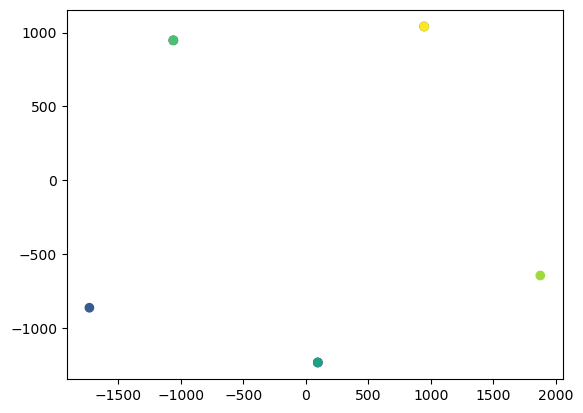

In [11]:
plt.scatter(points_tsne[:, 0], points_tsne[:, 1], c=labels)

# Import Data
coba dengan data asli

In [13]:
df = pd.read_csv("data/small_fmnist.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,...,pixel725,pixel726,pixel727,pixel728,pixel729,pixel730,pixel731,pixel732,pixel733,pixel734,pixel735,pixel736,pixel737,pixel738,pixel739,pixel740,pixel741,pixel742,pixel743,pixel744,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,1,2,0,0,0,0,0,114,183,112,55,23,72,102,165,160,28,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,24,188,163,93,136,153,168,252,174,136,166,130,123,131,66,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2,0,5,194,193,204,104,116,241,217,196,171,249,207,197,202,45,0,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,22,21,25,69,52,45,74,39,3,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,41,162,167,84,30,38,94,177,176,26,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,41,147,228,242,228,236,251,251,251,255,242,230,247,221,125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,240,233,228,235,232,229,228,229,231,231,231,228,229,212,0,0,1,0,0,0,0,0,0,0,0,0,0,0,101,157,148,148,167,180,182,179,176,172,171,164,177,163,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,142,205,52,0,0,0,0,19,171,187,41,0,0,0,3,0,0,0,0,0,0,0,...,4,0,0,0,0,0,3,0,21,167,184,185,186,184,198,132,41,67,70,73,84,240,194,186,181,192,133,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,6,15,13,5,10,0,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,40,122,0,0,0,0,0,0,0,28,146,43,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,129,193,122,0,0,0,0,0,0,145,183,125,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,153,195,183,172,176,172,169,171,169,171,171,176,180,189,193,139,0,0,0,0,0,0,0,0,0,0,0,0,80,133,155,159,157,162,157,161,161,163,151,145,125,93,87,49,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,2,112,139,176,171,173,196,218,118,40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,117,157,212,255,212,152,248,238,218,221,220,255,212,109,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,165,201,199,226,194,184,226,182,187,176,201,188,187,249,2,0,2,0,0,0,0,0,0,0,0,0,0,0,2,93,141,165,197,173,196,203,176,167,163,154,118,66,0,0,0,0,0,0,0


In [14]:
label2cat = {
    0 : "T-shirt/Top",
    1 : "Trouser",
    2 : "Pullover",
    3 : "Dress",
    4 : "Coat",
    5 : "Sandal",
    6 : "Shirt",
    7 : "Sneaker",
    8 : "Bag",
    9 : "Ankle Bot",
}

## Dataset Splitting

In [15]:
X = df.drop(columns="label")
y = df.label

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4000, 784), (1000, 784), (4000,), (1000,))

## Visualization with tSNE

In [16]:
tsne = TSNE(2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train)

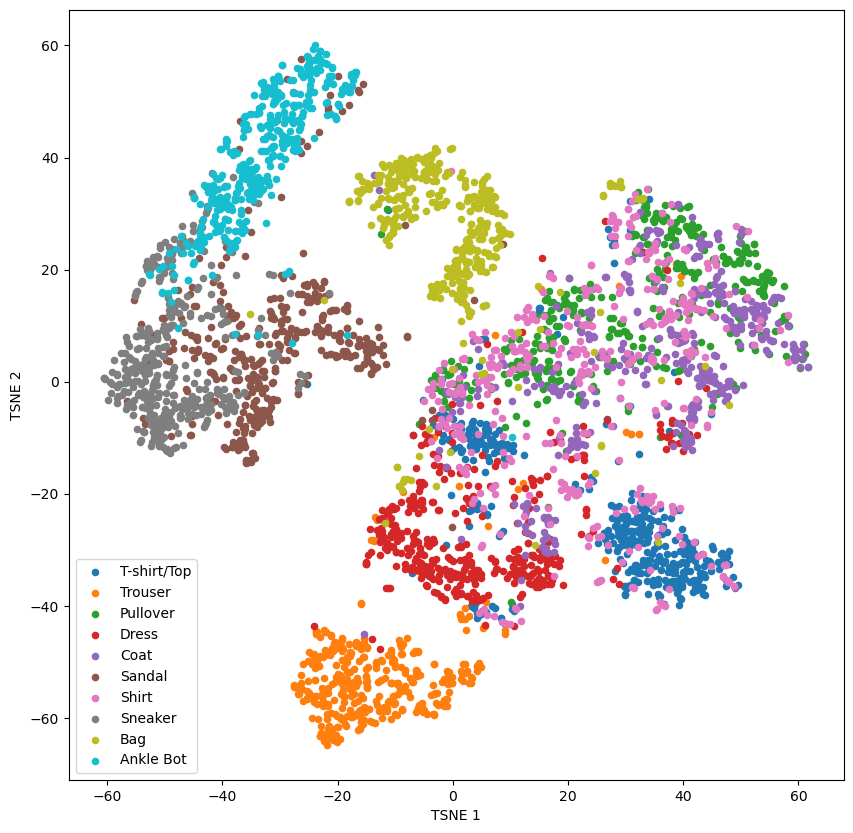

In [18]:
plt.figure(figsize=(10, 10))
for i in range(10):
    mask = y_train == i
    plt.scatter(X_train_tsne[mask, 0], X_train_tsne[mask, 1], s=20, label=label2cat[i])
plt.legend()
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2");